In [ ]:

!apt-get install -y r-base --quiet
!Rscript -e 'install.packages(c("bnlearn", "igraph"), repos="https://cloud.r-project.org")'

Reading package lists...
Building dependency tree...
Reading state information...
r-base is already the newest version (4.6.1-6.2404.0).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cloud.r-project.org/src/contrib/bnlearn_5.2.1.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/igraph_2.3.4.tar.gz'
* installing *source* package ‘bnlearn’ ...
** this is package ‘bnlearn’ version ‘5.2.1’
** package ‘bnlearn’ successfully unpacked and MD5 sums checked
** using staged installation
** libs
using C compiler: ‘x86_64-linux-gnu-gcc (Ubuntu 13.3.0-6ubuntu2~24.04.1) 13.3.0’
x86_64-linux-gnu-gcc -std=gnu17 -I"/usr/share/R/include" -DNDEBUG       -fpic  -g -O2 -fno-omit-frame-pointer -mno-omit-leaf-frame-pointer -ffile-prefix-map=/build/r-base-SRqRsK/r-base-4.6.1=. -fstack-protector-strong -fstack-clash-protection -Wformat -Werror=format-security -fcf-protection -fdebug

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ASRS_2017_2019.xlsx to ASRS_2017_2019.xlsx
Saving catssr_bn.R to catssr_bn.R


In [ ]:
import re
import pandas as pd

# Read the ASRS dataset
df_raw = pd.read_excel('ASRS_2017_2019.xlsx', header=[0, 1])

def find_col_by_fuzzy_match(df, group_pattern, field_pattern):
    for col in df.columns:
        if len(col) >= 2:
            g_match = re.search(group_pattern, str(col[0]), re.IGNORECASE)
            f_match = re.search(field_pattern, str(col[1]), re.IGNORECASE)
            if g_match and f_match:
                return col
    return None

anomaly_col = find_col_by_fuzzy_match(df_raw, "Events", "Anomaly")
result_col = find_col_by_fuzzy_match(df_raw, "Events", "Result")
hf_col1 = find_col_by_fuzzy_match(df_raw, "Person 1", "Human Factors")
hf_col2 = find_col_by_fuzzy_match(df_raw, "Person 2", "Human Factors")

print("Matched Anomaly Column:", anomaly_col)
print("Matched Result Column:", result_col)
print("Matched HF1 Column:", hf_col1)
print("Matched HF2 Column:", hf_col2)

# Direct mapping dictionary from raw text entries in the Excel to the standard taxonomy codes
RAW_RESULT_MAPPING = {
    "Air Traffic Control Issued Advisory / Alert": "RE14",
    "Air Traffic Control Issued New Clearance": "RE14",
    "Air Traffic Control Provided Assistance": "RE25",
    "Air Traffic Control Separated Traffic": "RE14",
    "Aircraft Aircraft Damaged": "RE32",
    "Aircraft Automation Overrode Flight Crew": "RE32",
    "Aircraft Equipment Problem Dissipated": "RE32",
    "Flight Crew Became Reoriented": "RE01",
    "Flight Crew Diverted": "RE17",
    "Flight Crew Executed Go Around / Missed Approach": "RE15",
    "Flight Crew Exited Penetrated Airspace": "RE15",
    "Flight Crew FLC Overrode Automation": "RE32",
    "Flight Crew FLC complied w / Automation / Advisory": "RE15",
    "Flight Crew Inflight Shutdown": "RE30",
    "Flight Crew Landed As Precaution": "RE18",
    "Flight Crew Landed in Emergency Condition": "RE20",
    "Flight Crew Overcame Equipment Problem": "RE32",
    "Flight Crew Overrode Automation": "RE32",
    "Flight Crew Regained Aircraft Control": "RE25",
    "Flight Crew Rejected Takeoff": "RE03",
    "Flight Crew Requested ATC Assistance / Clarification": "RE14",
    "Flight Crew Returned To Clearance": "RE14",
    "Flight Crew Returned To Departure Airport": "RE21",
    "Flight Crew Returned To Gate": "RE22",
    "Flight Crew Took Evasive Action": "RE04",
    "General Evacuated": "RE25",
    "General Flight Cancelled / Delayed": "RE17",
    "General Maintenance Action": "RE11",
    "General None Reported / Taken": "RE01",
    "General Physical Injury / Incapacitation": "RE29",
    "General Police / Security Involved": "RE13",
    "General Release Refused / Aircraft Not Accepted": "RE11",
    "General Work Refused": "RE16"
}

ANOMALY_AE_WE = {
    "AE01": "Aircraft Equipment Problem Critical",
    "AE02": "Aircraft Equipment Problem Less Severe",
    "AE03": "Airspace Structure",
    "AE04": "Conflict Airborne Conflict",
    "AE05": "Conflict Ground Conflict",
    "AE06": "Conflict NMAC",
    "AE07": "Environment - Non Weather Related",
    "AE08": "Facility",
    "AE09": "Ground Event / Encounter Animals",
    "AE10": "Ground Event / Encounter Debris / FOD",
    "AE11": "Ground Event / Encounter Foreign Object",
    "AE12": "Ground Event / Encounter Gear Up Land",
    "AE13": "Ground Event / Encounter Ground Strike",
    "AE14": "Ground Event / Encounter Jet Blast",
    "AE15": "Ground Event / Encounter Land Runway",
    "AE16": "Ground Event / Encounter Land Taxiway",
    "AE17": "Ground Event / Encounter Landed Off Runway",
    "AE18": "Ground Event / Encounter Loss of Control",
    "AE19": "Ground Event / Encounter Off Taxiway",
    "AE20": "Ground Event / Encounter Runway Excursion",
    "AE21": "Ground Event / Encounter Runway Incursion",
    "AE22": "Flight Deck / Cabin / Aircraft Event Smoke / Fire / Fumes / Odor",
    "AE23": "Ground Event / Encounter Aircraft",
    "AE24": "Ground Event / Encounter Apron / Ramp / Gate",
    "AE25": "Ground Event / Encounter Equipment",
    "AE26": "Ground Event / Encounter Maintenance",
    "AE27": "Ground Event / Encounter Marshaller",
    "AE28": "Ground Event / Encounter Object",
    "AE29": "Ground Event / Encounter Person",
    "AE30": "Ground Event / Encounter Tow Bar",
    "AE31": "Ground Event / Encounter Vehicle",
    "AE32": "Inflight Event / Encounter Fuel Issue",
    "AE33": "Inflight Event / Encounter Ground Proximity",
    "AE34": "Inflight Event / Encounter Loss of Control",
    "AE35": "Inflight Event / Encounter Malfunction",
    "AE36": "Inflight Event / Encounter Microburst",
    "AE37": "Inflight Event / Encounter SFTY / SEC",
    "AE38": "Inflight Event / Encounter Turbulence",
    "AE39": "Inflight Event / Encounter VFR in IMC",
    "AE40": "Inflight Event / Encounter Weather",
    "AE41": "Inflight Event / Encounter Windshear",
    "AE42": "Manuals",
    "AE43": "No Anomaly / Non-Anomaly Occurrence",
    "WE01": "Weather Forecast / Advisory",
    "WE02": "Weather Visibility / Ceiling",
    "WE03": "Weather Wind / Turbulence / Gusts",
}
HUMANFACTORS_HE = {
    "HE01": "Communication Breakdown",
    "HE02": "Confusion",
    "HE03": "Distraction",
    "HE04": "Fatigue",
    "HE05": "Illness",
    "HE06": "Physiological - Other",
    "HE07": "Situational Awareness",
    "HE08": "Time Pressure",
    "HE09": "Training / Qualification",
    "HE10": "Workload",
    "HE11": "Human Factors - Other",
}
ANOMALY_HE = {
    "HE12": "Flight Deck / Cabin / Aircraft Event Illness / Injury",
    "HE13": "ATC Issue Airspace Structure",
    "HE14": "ATC Issue Assistant / Co-worker",
    "HE15": "ATC Issue Automation / Technology",
    "HE16": "ATC Issue Equipment / Tool / Graphic",
    "HE17": "ATC Issue Facility / Environment",
    "HE18": "ATC Issue All Types",
}

def get_tokens(series):
    out = []
    for val in series:
        if pd.isna(val):
            out.append(set())
        else:
            tokens = {re.sub(r'[^a-z0-9]', '', part.strip().lower()) for part in str(val).split(';') if part.strip()}
            out.append(tokens)
    return out

anomaly_rows = get_tokens(df_raw[anomaly_col])
hf1_rows = get_tokens(df_raw[hf_col1])
hf2_rows = get_tokens(df_raw[hf_col2]) if hf_col2 else [set()] * len(df_raw)

bn_dict = {}
node_family = {}

for code, desc in ANOMALY_AE_WE.items():
    norm_key = re.sub(r'[^a-z0-9]', '', desc.lower())
    bn_dict[code] = [int(norm_key in row) for row in anomaly_rows]
    node_family[code] = "causal"

for code, desc in HUMANFACTORS_HE.items():
    norm_key = re.sub(r'[^a-z0-9]', '', desc.lower())
    bn_dict[code] = [int(norm_key in r1 or norm_key in r2) for r1, r2 in zip(hf1_rows, hf2_rows)]
    node_family[code] = "causal"

for code, desc in ANOMALY_HE.items():
    norm_key = re.sub(r'[^a-z0-9]', '', desc.lower())
    bn_dict[code] = [int(norm_key in row) for row in anomaly_rows]
    node_family[code] = "causal"

# Dynamic Mapping for Results using mapped unique terms
raw_results = df_raw[result_col].fillna("").astype(str)
for code in [f"RE{i:02d}" for i in range(1, 33)]:
    # Find all Excel-reported raw entries that are mapped to this code
    mapped_strings = [raw for raw, re_code in RAW_RESULT_MAPPING.items() if re_code == code]
    # Mark 1 if any of those mapped phrases appear in the row value
    indicators = []
    for row_val in raw_results:
        row_parts = [p.strip() for p in row_val.split(';') if p.strip()]
        has_match = any(any(s == part for s in mapped_strings) for part in row_parts)
        indicators.append(int(has_match))
    bn_dict[code] = indicators
    node_family[code] = "result"

bn_df = pd.DataFrame(bn_dict)
print(f"Corrected binary matrix constructed: {bn_df.shape[0]} rows x {bn_df.shape[1]} columns.")

result_codes = set([f"RE{i:02d}" for i in range(1, 33)])
zero_cols = [col for col in bn_df.columns if bn_df[col].sum() == 0]
zero_causal_cols = [c for c in zero_cols if c not in result_codes]
if zero_causal_cols:
    bn_df = bn_df.drop(columns=zero_causal_cols)

bn_df.to_csv("bn_matrix.csv", index=False)
pd.DataFrame(
    [(k, "result" if k in result_codes else "causal") for k in bn_df.columns],
    columns=["node", "family"]
).to_csv("node_family.csv", index=False)
print("Saved updated and correctly mapped bn_matrix.csv and node_family.csv!")

Matched Anomaly Column: ('Events', 'Anomaly')
Matched Result Column: ('Events.5', 'Result')
Matched HF1 Column: ('Person 1.7', 'Human Factors')
Matched HF2 Column: ('Person 2.7', 'Human Factors')
Corrected binary matrix constructed: 8913 rows x 96 columns.
Saved updated and correctly mapped bn_matrix.csv and node_family.csv!


In [ ]:
!Rscript catssr_bn.R

import pandas as pd
try:
    table3 = pd.read_csv('table3_high_risk_causal_factors.csv')
    print('\n--- Updated Table 3 Results (Sample) ---')
    print(table3.head(15))
except Exception as e:
    print('Could not load table 3:', e)


Attaching package: ‘igraph’

The following objects are masked from ‘package:bnlearn’:

    as.igraph, compare, degree, subgraph

The following objects are masked from ‘package:stats’:

    decompose, spectrum

The following object is masked from ‘package:base’:

    union

STEP 1: Loading binary matrix
Loaded 8913 incidents x 54 nodes.
22 causal-factor nodes, 32 result-event nodes.

STEP 2: Building blacklist (no result<->result edges)
Blacklisted 992 directed result<->result edges.

STEP 3: Structure learning (MMHC, bnlearn native implementation)
There were 30 warnings (use warnings() to see them)
MMHC structure learning finished in 2.7 seconds.
Learned 41 edges across 54 nodes.

Learned edges (parent/independent -> child/dependent):
  HE18     -> RE14
  AE02     -> HE18
  AE01     -> RE20
  HE08     -> HE10
  HE06     -> HE12
  HE18     -> RE11
  HE18     -> AE04
  HE18     -> HE01
  AE01     -> AE02
  AE01     -> HE18
  AE02     -> RE20
  AE02     -> RE11
  RE18     -> AE02
  AE01 

### Interactive Safety Budget Allocation
Enter your available safety improvement budget below to see how to dynamically distribute it among the hazard causal factors to achieve the maximum possible risk reduction.

---
# Reproduction of Zhou et al. (2023), *Safety Science* 157, 105942 — checks and additions
Everything below is new; cells 0–7 are unchanged and none of their files is overwritten (new files start with `paper_`).
Run the cells below **in order**.

| Step | Cell | Paper item |
|---|---|---|
| 1 | Setup + comparison with the first run | – |
| 2 | Paper filters + Appendix I/II matrix | Sec. 2, Appendix I–II |
| 3 | MMHC, RSMAX2, 10-fold CV (R) | Sec. 3.1.1, 4.1, 4.2 |
| 4 | Tables 1–2, Figs. 1 and 3 | Sec. 4.1–4.2 |
| 5 | Tables 3–4 (mutual information) | Sec. 4.3–4.4 |
| 6 | Table 5, Figs. 5–6, investment plan | Sec. 3.2, 4.4 |
| 7 | Fig. 4 | Sec. 4.4 |
| 8–9 | Definition checks + `iss`/`alpha` sensitivity | where the paper is not explicit |

**Why the first run differed from the paper:** the label lists in cell 2 were not the paper's Appendix I/II (42 causal columns matched
nothing, several result codes were merged), so result nodes such as `RE05` were empty and Table 3 showed N/A.
**Still not reproducible from the paper's text:** the exact 7,265-incident subset, W* = 2.88, the Table 3 percentage denominators,
the Table 4 value definition, the way the risk coefficients k were computed, and the risk levels behind Fig. 4.

In [ ]:
# ── MMHC + RSMAX2 structure learning and 10-fold CV (R / bnlearn, new script file) ──
R_MAIN = r'''
options(warn = -1); suppressPackageStartupMessages(library(bnlearn)); set.seed(42)
d <- read.csv("bn_matrix_paper.csv", check.names = FALSE, stringsAsFactors = FALSE)
for (n in names(d)) d[[n]] <- factor(d[[n]], levels = c(0, 1))
const <- sapply(d, function(x) { s <- sum(x == "1"); s == 0 || s == nrow(d) })
cat("Rows:", nrow(d), " Columns:", ncol(d), " Constant columns excluded:", sum(const), "\n")
write.csv(data.frame(node = names(d)[const]), "paper_excluded_nodes.csv", row.names = FALSE)
dk <- d[, !const, drop = FALSE]
res <- grep("^RE", names(dk), value = TRUE)
bl <- expand.grid(from = res, to = res, stringsAsFactors = FALSE); bl <- bl[bl$from != bl$to, ]   # no result -> result edges
ma <- list(score = "bde", iss = 10)                                                                    # BDeu, same iss as catssr_bn.R

save_arcs <- function(net, file) {
  a <- as.data.frame(arcs(net), stringsAsFactors = FALSE)
  if (nrow(a) == 0) a <- data.frame(from = character(0), to = character(0))
  names(a) <- c("from", "to"); write.csv(a, file, row.names = FALSE); nrow(a)
}
cat("MMHC edges:",   save_arcs(mmhc(dk, blacklist = bl, maximize.args = ma),   "paper_bn_edges.csv"), "\n")
cat("RSMAX2 edges:", save_arcs(rsmax2(dk, blacklist = bl, maximize.args = ma), "paper_bn_edges_rsmax2.csv"), "\n")

cv_losses <- function(alg) tryCatch({
  cv <- bn.cv(dk, bn = alg, algorithm.args = list(blacklist = bl, maximize.args = ma), loss = "logl", k = 10, runs = 1,
              fit = "bayes", fit.args = list(iss = 10))
  if (inherits(cv, "bn.kcv.list")) cv <- cv[[1]]
  as.numeric(sapply(cv, function(f) f$loss))
}, error = function(e) { cat("CV failed for", alg, ":", conditionMessage(e), "\n"); rep(NA_real_, 10) })
out <- data.frame(fold = 1:10, MMHC = cv_losses("mmhc"), RSMAX2 = cv_losses("rsmax2"))
write.csv(out, "paper_kfold_per_fold.csv", row.names = FALSE); print(colMeans(out[, -1]))
'''
run_r("catssr_bn_paper.R", R_MAIN)

Rows: 8911  Columns: 96  Constant columns excluded: 1 
MMHC edges: 110 
RSMAX2 edges: 106 
    MMHC   RSMAX2 
16.39409 16.53876 



True

Table 1 - priors (paper: HE07 .603, HE16 .589, HE01 .358, AE02 .249, HE18 .244, AE12 .225, HE02 .203)


,Node,Prior,Node,Prior,Node,Prior,Node,Prior
0,AE01,0.091,AE17,0.012,AE33,0.055,HE06,0.035
1,AE02,0.285,AE18,0.011,AE34,0.030,HE07,0.435
2,AE03,0.014,AE19,0.029,AE35,0.013,HE08,0.110
3,AE04,0.062,AE20,0.051,AE36,0.002,HE09,0.063
4,AE05,0.026,AE21,0.078,AE37,0.011,HE10,0.095
5,AE06,0.021,AE22,0.087,AE38,0.046,HE11,0.123
6,AE07,0.023,AE23,0.004,AE39,0.000,HE12,0.054
7,AE08,0.024,AE24,0.002,AE40,0.002,HE13,0.037
8,AE09,0.038,AE25,0.000,AE41,0.001,HE14,0.004
9,AE10,0.026,AE26,0.004,AE42,0.014,HE15,0.013



Table 2 - CPT of RE21 (paper parents: AE09, AE10, AE12, AE21, AE33)


,AE09,AE10,AE12,AE21,RE21=0,RE21=1,n obs
0,0,0,0,0,0.988,0.012,7059
1,0,0,0,1,0.875,0.125,120
2,0,0,1,0,0.876,0.124,659
3,0,0,1,1,0.576,0.424,514
4,0,1,0,0,0.610,0.390,41
5,0,1,0,1,0.667,0.333,3
6,0,1,1,0,0.531,0.469,160
7,0,1,1,1,0.583,0.417,12
8,1,0,0,0,0.773,0.227,150
9,1,0,0,1,0.909,0.091,11


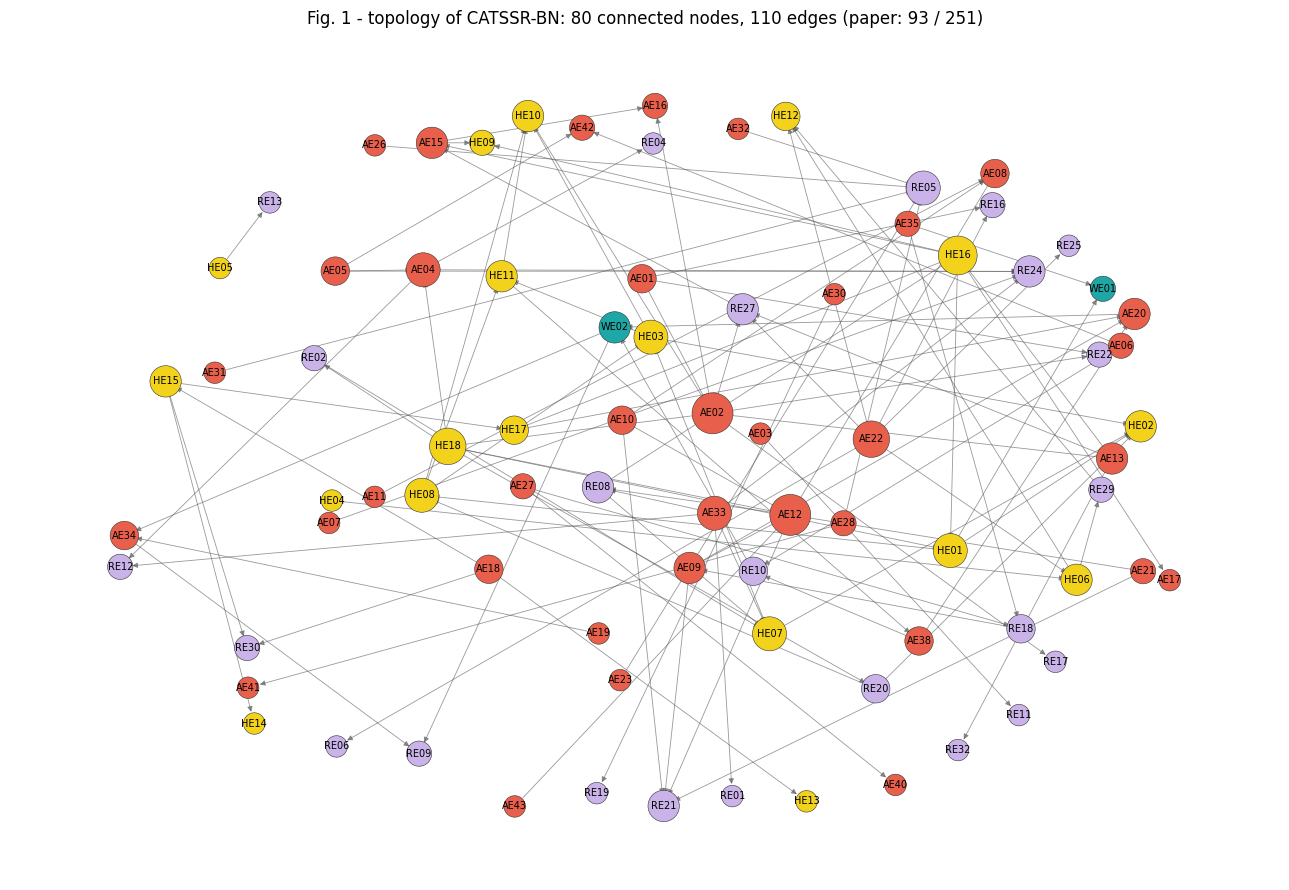

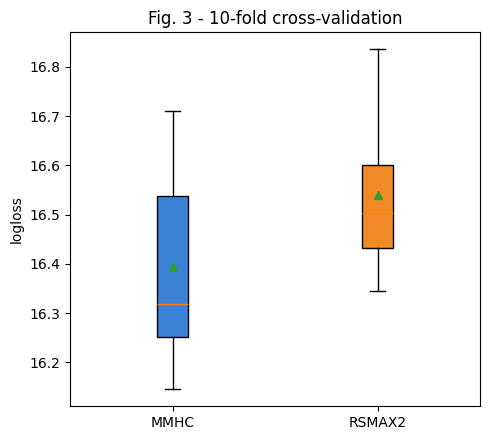

{'MMHC': 16.394, 'RSMAX2': 16.539} -> MMHC lower (as in the paper)


In [ ]:
# ── Table 1, Table 2, Fig. 1, Fig. 3 ──────────────────────────────────────────────
B, E = pd.read_csv("bn_matrix_paper.csv"), pd.read_csv("paper_bn_edges.csv")
causal = [c for c in B.columns if not c.startswith("RE")]; result = [c for c in B.columns if c.startswith("RE")]

# Table 1: prior probability of every causal factor event (printed as 4 blocks of 16)
t1 = pd.DataFrame({"Node": causal, "Prior": B[causal].mean().round(3).values}); t1.to_csv("paper_table1_priors.csv", index=False)
print("Table 1 - priors (paper: HE07 .603, HE16 .589, HE01 .358, AE02 .249, HE18 .244, AE12 .225, HE02 .203)")
display(pd.concat([t1.iloc[i:i + 16].reset_index(drop=True) for i in range(0, 64, 16)], axis=1))

# Table 2: CPT of RE21 by maximum likelihood; parent combinations never observed get 0.5/0.5
parents = sorted(E.loc[E["to"] == "RE21", "from"])
if parents:
    rows = []
    for combo in itertools.product([0, 1], repeat=len(parents)):
        m = np.all(B[parents].values == combo, axis=1); n = int(m.sum()); p1 = B.loc[m, "RE21"].mean() if n else 0.5
        rows.append(list(combo) + [round(1 - p1, 3), round(p1, 3), n])
    t2 = pd.DataFrame(rows, columns=parents + ["RE21=0", "RE21=1", "n obs"]); t2.to_csv("paper_table2_cpt.csv", index=False)
    print(f"\nTable 2 - CPT of RE21 (paper parents: AE09, AE10, AE12, AE21, AE33)"); display(t2)
else:
    print("RE21 has no parents in the learned network.")

# Fig. 1: topology (colour = family, size = degree)
G = nx.DiGraph(zip(E["from"], E["to"])); pal = {"AE": "#e8604c", "HE": "#f2d21b", "WE": "#1fa6a6", "RE": "#c9b3e8"}
plt.figure(figsize=(13, 9)); pos = nx.spring_layout(G, seed=7, k=0.9)
nx.draw_networkx_edges(G, pos, arrowsize=8, width=0.6, alpha=0.6, edge_color="#555")
nx.draw_networkx_nodes(G, pos, node_size=[150 + 90 * G.degree(n) for n in G], node_color=[pal[n[:2]] for n in G], edgecolors="#333", linewidths=0.4)
nx.draw_networkx_labels(G, pos, font_size=7)
plt.title(f"Fig. 1 - topology of CATSSR-BN: {G.number_of_nodes()} connected nodes, {G.number_of_edges()} edges (paper: 93 / 251)")
plt.axis("off"); plt.tight_layout(); plt.savefig("paper_fig1_topology.png", dpi=150); plt.show()

# Fig. 3: 10-fold CV log-loss
cv = pd.read_csv("paper_kfold_per_fold.csv")
if cv[["MMHC", "RSMAX2"]].isna().any().any(): raise RuntimeError("Cross-validation failed in R - see the output of the previous cell.")
plt.figure(figsize=(5, 4.5)); bp = plt.boxplot([cv["MMHC"], cv["RSMAX2"]], patch_artist=True, showmeans=True)
plt.xticks([1, 2], ["MMHC", "RSMAX2"]); plt.ylabel("logloss"); plt.title("Fig. 3 - 10-fold cross-validation")
for b, col in zip(bp["boxes"], ["#3b82d6", "#f08a24"]): b.set_facecolor(col)
plt.tight_layout(); plt.savefig("paper_fig3_cv.png", dpi=150); plt.show()
m = cv[["MMHC", "RSMAX2"]].mean(); print(m.round(3).to_dict(), "->", "MMHC lower (as in the paper)" if m["MMHC"] < m["RSMAX2"] else "RSMAX2 lower (paper: MMHC lower)")

In [ ]:
# ── Tables 3 and 4: mutual information ────────────────────────────────────────────
def mutual_info(X, R):
    # MI (LOG_BASE) between every column of X and every column of R (binary 0/1 matrices)
    n = len(X); n11 = X.T @ R; a = X.sum(0)[:, None]; b = R.sum(0)[None, :]
    mi = np.zeros_like(n11)
    for cnt, px, py in [(n11, a, b), (a - n11, a, n - b), (b - n11, n - a, b), (n - a - b + n11, n - a, n - b)]:
        pxy = cnt / n
        with np.errstate(divide="ignore", invalid="ignore"): mi += np.where(pxy > 0, pxy * np.log(pxy / (px / n * py / n)), 0.0)
    return mi / np.log(LOG_BASE)

MI = pd.DataFrame(mutual_info(B[causal].values.astype(float), B[result].values.astype(float)), index=causal, columns=result)
MI.to_csv("paper_mi_matrix.csv")

t3 = []
for r in HIGH_RISK:
    if MI[r].sum() <= 0: raise ValueError(f"{r} has no incidents/dependence - check paper_taxonomy_coverage.csv")
    t3 += [(r, c, round(v, 5), round(100 * v / MI[r].sum(), 2)) for c, v in MI[r].nlargest(5).items()]
t3 = pd.DataFrame(t3, columns=["Result event", "Causal factor event", "Mutual information", "Percentage (%)"]); t3.to_csv("paper_table3.csv", index=False)
print("Table 3 - strongest causal factors of the high-risk result events"); display(t3)

t4 = MI.sum(axis=1).nlargest(10).rename("Mutual information").to_frame()
t4["Percentage (%)"] = 100 * t4["Mutual information"] / MI.values.sum()
t4 = t4.round(3).rename_axis("ID").reset_index(); t4.to_csv("paper_table4.csv", index=False)
print("\nTable 4 - top-10 causal factors by total MI (paper: AE12, AE15, AE01, AE04, HE12, HE16, AE33, AE13, AE22, AE23)"); display(t4)
assert not (t3.isna().any().any() or t4.isna().any().any())

Table 3 - strongest causal factors of the high-risk result events


,Result event,Causal factor event,Mutual information,Percentage (%)
0,RE04,AE04,0.03935,29.74
1,RE04,HE18,0.03722,28.12
2,RE04,AE02,0.00831,6.28
3,RE04,HE07,0.00662,5.00
4,RE04,AE03,0.00392,2.96
5,RE05,AE28,0.01540,13.39
6,RE05,AE23,0.01344,11.69
7,RE05,AE31,0.01322,11.50
8,RE05,HE18,0.00936,8.14
9,RE05,AE32,0.00831,7.23



Table 4 - top-10 causal factors by total MI (paper: AE12, AE15, AE01, AE04, HE12, HE16, AE33, AE13, AE22, AE23)


,ID,Mutual information,Percentage (%)
0,AE12,0.399,8.888
1,HE18,0.378,8.430
2,AE01,0.254,5.656
3,AE02,0.245,5.457
4,AE21,0.224,4.981
5,AE22,0.198,4.418
6,AE04,0.164,3.643
7,HE16,0.147,3.276
8,HE07,0.146,3.256
9,AE33,0.140,3.112


Table 5 (paper: negative k for AE15, HE16, AE13)


,Causal factor event,Resource investment,Risk coefficient
0,AE12,5.86,-0.06
1,HE18,5.21,0.01
2,AE01,11.04,0.12
3,AE02,3.51,-0.02
4,AE21,12.80,-0.05
5,AE22,11.44,0.04
6,AE04,16.20,0.14
7,HE16,1.84,-0.04
8,HE07,2.30,0.00
9,AE33,18.30,-0.08


Excluded (k <= 0): ['AE12', 'AE02', 'AE21', 'HE16', 'HE07', 'AE33']
Factors in the model: ['HE18', 'AE01', 'AE22', 'AE04'] | max reachable risk reduction R_max = 0.0218
The paper's alpha range 0.05-0.20 is not reachable here, so the axis is rescaled to 25%-95% of R_max.


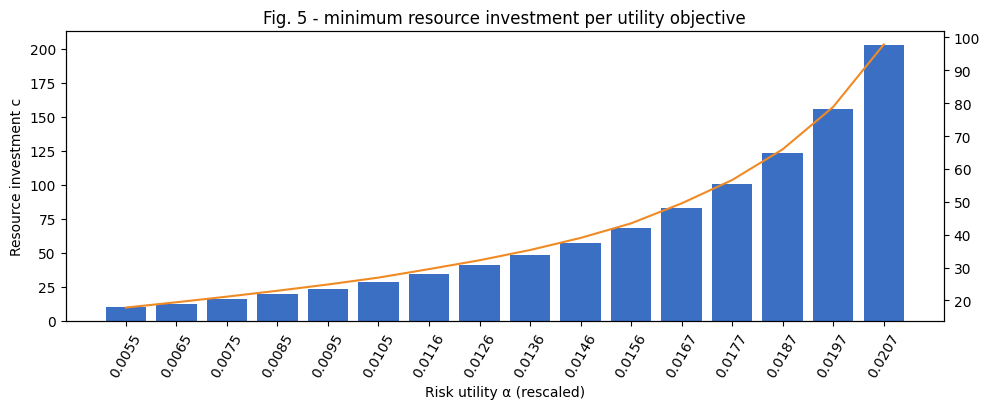

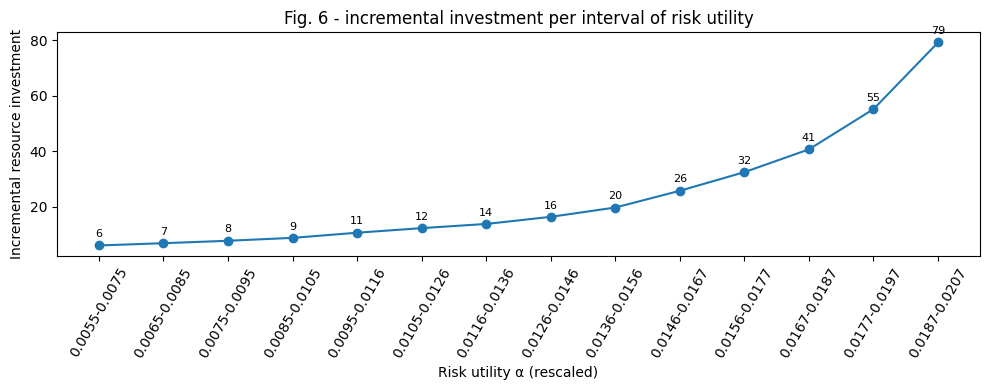


alpha* = 0.0187 -> total 126 units (paper: X = {18,17,14,16,3} for AE12, AE04, AE01, HE12, AE22; total 68)


,Causal factor event,Resource investment,Risk coefficient,Newly invested x_i,s_i + x_i
1,AE01,11.04,0.12,46,57.04
3,AE04,16.20,0.14,46,62.20
2,AE22,11.44,0.04,22,33.44
0,HE18,5.21,0.01,12,17.21


In [ ]:
# ── Table 5, Fig. 5, Fig. 6 and the investment plan (paper Sec. 3.2 / 4.4) ─────────
# s_i = 1/P(E_i) (Eq.15, a = 0, b = 1); k_i = sum over the high-risk results of P(R|E=1) - P(R|E=0) (Eq.16-17, an assumption: the paper does not print the formula)
def risk_coefficient(f):
    e = B[f].values == 1
    return float((B.loc[e, HIGH_RISK].mean() - B.loc[~e, HIGH_RISK].mean()).sum()) if 0 < e.sum() < len(B) else 0.0

t5 = pd.DataFrame({"Causal factor event": t4["ID"],
                   "Resource investment": [round(min(1 / B[f].mean(), C_STAR), 2) for f in t4["ID"]],
                   "Risk coefficient": [round(risk_coefficient(f), 2) for f in t4["ID"]]})
t5.to_csv("paper_table5.csv", index=False)
print("Table 5 (paper: negative k for AE15, HE16, AE13)"); display(t5)
use = t5[t5["Risk coefficient"] > 0].reset_index(drop=True)          # factors with k <= 0 cannot reduce risk -> excluded, as in the paper
print("Excluded (k <= 0):", list(t5.loc[t5["Risk coefficient"] <= 0, "Causal factor event"]))
if use.empty: raise RuntimeError("No factor has k > 0 - nothing to optimise.")
k, s = use["Risk coefficient"].values, use["Resource investment"].values

# min sum x_i  s.t.  sum k_i/(s_i+x_i) <= W* - alpha,  s_i + x_i <= C*  (W* = current modelled risk; exact solution via the Lagrange multiplier)
def plan(alpha):
    lo, hi = 0.0, 1e12
    for _ in range(200):
        mid = (lo + hi) / 2
        if (k * (1 / s - 1 / np.clip(np.sqrt(mid * k), s, C_STAR))).sum() >= alpha: hi = mid
        else: lo = mid
    return np.clip(np.sqrt(hi * k), s, C_STAR) - s

R_MAX = float((k * (1 / s - 1 / C_STAR)).sum())
rescaled = R_MAX < 0.20
alphas = np.round(np.linspace(0.25 * R_MAX, 0.95 * R_MAX, 16), 4) if rescaled else np.round(np.arange(0.05, 0.2001, 0.01), 2)
print(f"Factors in the model: {list(use['Causal factor event'])} | max reachable risk reduction R_max = {R_MAX:.4f}"
      + ("\nThe paper's alpha range 0.05-0.20 is not reachable here, so the axis is rescaled to 25%-95% of R_max." if rescaled else ""))
costs = np.array([plan(a).sum() for a in alphas]); xl = "Risk utility α" + (" (rescaled)" if rescaled else "")

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.bar([str(a) for a in alphas], costs, color="#3b6fc4"); ax.set_xlabel(xl); ax.set_ylabel("Resource investment c"); plt.setp(ax.get_xticklabels(), rotation=60)
ax.twinx().plot([str(a) for a in alphas], costs / (alphas * 100), color="#f08a24"); ax.set_title("Fig. 5 - minimum resource investment per utility objective")
plt.tight_layout(); plt.savefig("paper_fig5.png", dpi=150); plt.show()

inc = [(alphas[i], alphas[i + 2], costs[i + 2] - costs[i]) for i in range(len(alphas) - 2)]      # increment over two grid steps (= 0.02 in the paper)
plt.figure(figsize=(10, 4)); plt.plot([f"{a}-{b}" for a, b, _ in inc], [v for *_, v in inc], marker="o")
for i, (*_, v) in enumerate(inc): plt.annotate(f"{v:.0f}", (i, v), textcoords="offset points", xytext=(0, 6), ha="center", fontsize=8)
plt.xticks(rotation=60); plt.xlabel(xl); plt.ylabel("Incremental resource investment"); plt.title("Fig. 6 - incremental investment per interval of risk utility")
plt.tight_layout(); plt.savefig("paper_fig6.png", dpi=150); plt.show()

ALPHA_STAR = None                                                   # the paper picks the knee by eye (0.15); None = largest jump of the increments
if ALPHA_STAR is None:
    ALPHA_STAR = inc[int(np.argmax(np.diff([v for *_, v in inc]))) + 1][0]
x = np.ceil(plan(ALPHA_STAR)).astype(int)
final = use.assign(**{"Newly invested x_i": x, "s_i + x_i": (s + x).round(2)}).query("`Newly invested x_i` > 0").sort_values("Newly invested x_i", ascending=False)
print(f"\nalpha* = {ALPHA_STAR} -> total {int(final['Newly invested x_i'].sum())} units (paper: X = {{18,17,14,16,3}} for AE12, AE04, AE01, HE12, AE22; total 68)")
display(final); final.to_csv("paper_final_investment.csv", index=False)

,Medium,Moderately high,High,Low,Moderately medium,No result event
% of incidents,29.9,24.1,18.1,16.8,5.8,5.3


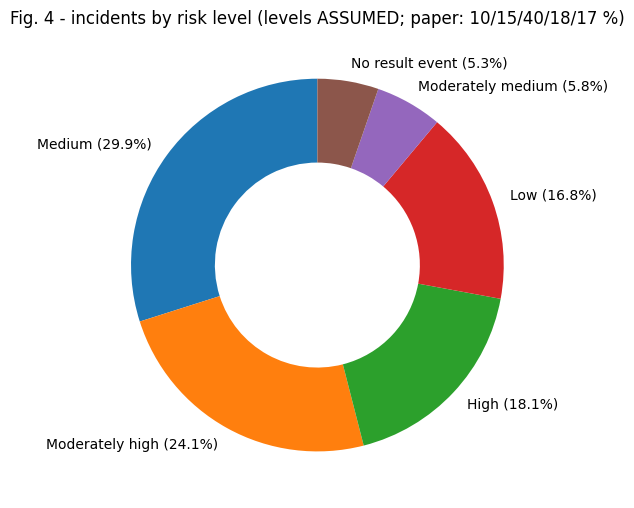

In [ ]:
# ── Fig. 4: incidents by risk level ───────────────────────────────────────────────
# ASSUMED classification. The paper (Sec. 4.3) names only the four High events RE04, RE05, RE14, RE29 (from Zhang & Mahadevan, 2019).
# Every other entry below was assigned by the notebook author, NOT taken from the paper - replace with the published table if you have it.
ASSUMED_LEVELS = {
    "High":              ["RE04", "RE05", "RE14", "RE29", "RE16", "RE25", "RE30"],
    "Moderately high":   ["RE15", "RE20", "RE22", "RE24", "RE32"],
    "Medium":            ["RE01", "RE02", "RE03", "RE09", "RE10", "RE11", "RE17", "RE21", "RE23", "RE27"],
    "Moderately medium": ["RE06", "RE07", "RE08", "RE12", "RE13", "RE18", "RE19"],
    "Low":               ["RE26", "RE28", "RE31"]}
levels = list(ASSUMED_LEVELS)
rank = {r: levels.index(l) for l, rs in ASSUMED_LEVELS.items() for r in rs}
worst = B[result].apply(lambda row: min((rank[c] for c in result if row[c] == 1 and c in rank), default=-1), axis=1)   # worst result event of each incident
share = worst.map(lambda i: levels[i] if i >= 0 else "No result event").value_counts(normalize=True).mul(100).round(1)
display(share.rename("% of incidents").to_frame().T)
plt.figure(figsize=(6, 6)); plt.pie(share.values, labels=[f"{i} ({v:.1f}%)" for i, v in share.items()], wedgeprops=dict(width=0.45), startangle=90)
plt.title("Fig. 4 - incidents by risk level (levels ASSUMED; paper: 10/15/40/18/17 %)"); plt.tight_layout(); plt.savefig("paper_fig4.png", dpi=150); plt.show()

In [ ]:
#@title Enter Safety Budget for Allocation { run: "auto" }

#@markdown Enter the total budget you want to allocate:
budget_input = 150000000 #@param {type:"number"}

#@markdown ---
#@markdown (Optional) Adjust safety baseline factor if needed:
safety_limit = 0.5 #@param {type:"slider", min:0.1, max:1.0, step:0.05}

try:
    # Run allocation
    results = allocate_budget(new_budget_input=budget_input, safety_limit_factor=safety_limit)
    display(results)
except NameError:
    print("Error: The 'allocate_budget' function is not defined in the workspace. Please run the cell containing the function definition first.")
except Exception as e:
    print(f"An error occurred: {e}")


=== Optimization Results for New Budget: 150000000 ===
Total initial risk score: 0.6128
Total optimized risk score: 0.0000
Safety risk reduced by: 100.00%


,Causal_Factor,Risk_Coefficient_Ki,Baseline_Investment_Si,Allocated_Budget_Xi,Baseline_Risk_Score,Optimized_Risk_Score
4,AE04,0.634357,16.205455,10500000.0,0.039145,6.041481e-08
0,HE18,0.590539,5.215331,10050000.0,0.113231,5.876008e-08
6,HE12,0.560261,18.685535,9750000.0,0.029984,5.746252e-08
14,AE06,0.559953,43.691176,9750000.0,0.012816,5.743084e-08
11,HE06,0.509030,28.476038,9300000.0,0.017876,5.473428e-08
19,AE23,0.443781,240.891892,8700000.0,0.001842,5.100790e-08
12,AE05,0.381139,21.425481,8100000.0,0.017789,4.705404e-08
18,AE28,0.361796,174.764706,7950000.0,0.002070,4.550792e-08
5,AE22,0.352364,11.441592,7800000.0,0.030797,4.517480e-08
20,AE31,0.308460,185.687500,7350000.0,0.001661,4.196632e-08
